In [1]:
# celelb에서 이미지 읽어오는 Dataloader 만들기
# vae latent shape에 대응하도록 모델 짜기
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from tqdm import tqdm
from diffusers import AutoencoderKL
import os
from utils.utils import visualize
from utils.sample import ddim_sample, x_t_sample
import torch.nn.functional as F
from dataset import CelebDataset
from torchvision import transforms
from utils.schedule import linear_beta_schedule, cosine_beta_schedule
from ldm.attention import DiT
from einops import rearrange
import time
from functools import partial

from types import SimpleNamespace

def count_parameters(model: nn.Module, only_trainable: bool = True):
    return f"{round(sum(p.numel() for p in model.parameters() if p.requires_grad or not only_trainable)/1000000, 3)}M"

cfg = {
    "in_dim":4,
    "model_dim": 512,
    "depth":20,
    "num_heads":8,
    "batch_size": 256,
    "learning_rate": 5e-5,
    "epochs": 1000,
    "total_timesteps": 1000,
    "beta_0": 0.0001,
    "beta_T": 0.02,
    "sampling_steps": 1000,
    "latent_scale": 0.18215,
    "output_dir": "./logs_dit_0521_mnist_latent_zero",
    "beta_1": 0.9,
    "beta_2": 0.99,
    'weight_decay': 0.01,
}
cfg = SimpleNamespace(**cfg)

In [2]:
device = 'cuda'

# downsampling rate=8, latent_dim=4
vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae").to(device)
vae.eval()

model = DiT(
    in_dim=cfg.in_dim, 
    model_dim=cfg.model_dim, 
    depth=cfg.depth, 
    num_heads=cfg.num_heads
)
model.to(device)
print(count_parameters(model))

os.makedirs(cfg.output_dir, exist_ok=True)
os.makedirs(f"{cfg.output_dir}/valid_imgs/", exist_ok=True)
os.makedirs(f"{cfg.output_dir}/weights/", exist_ok=True)

with open(f"{cfg.output_dir}/model_structure.txt", "a") as f:
    print(model, file=f)

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, betas=(cfg.beta_1, cfg.beta_2), weight_decay=cfg.weight_decay)

trainer = {
    'train_losses': [],
    'valid_losses': [],
    'valid_images': [],
}

94.418M


In [3]:
from datasets import load_dataset
from torchvision import transforms
from torch.utils.data import DataLoader
from PIL import Image
import cv2
import torch

def load_image_as_tensor(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)  # BGR 형식
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # RGB로 변환
    img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0  # (H, W, C) -> (C, H, W)
    return img

transform = transforms.Compose([
    transforms.Resize(64, antialias=True),
    transforms.CenterCrop(64),
    transforms.RandomHorizontalFlip(p=0.1)
])

class CelebDataset(torch.utils.data.Dataset):
    def __init__(self, data_paths, transform=None):
        self.dataset = data_paths
        self.transform = transform
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        try:
            img = load_image_as_tensor(self.dataset[idx])
        except Exception as e:
            print("Error : ", e)
            return self.__getitem__(idx + 1)
        return self.transform(img)

train_paths = [f'img_align_celeba/{i:06d}.jpg' for i in range(162770)]
valid_paths = [f'img_align_celeba/{i:06d}.jpg' for i in range(162771, 182637)]
train_dataset = CelebDataset(train_paths, transform)
valid_dataset = CelebDataset(valid_paths, transform)

train_dataloader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, num_workers=8)
valid_dataloader = DataLoader(valid_dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=8)

betas :  torch.Size([1000])
alphas :  torch.Size([1000])


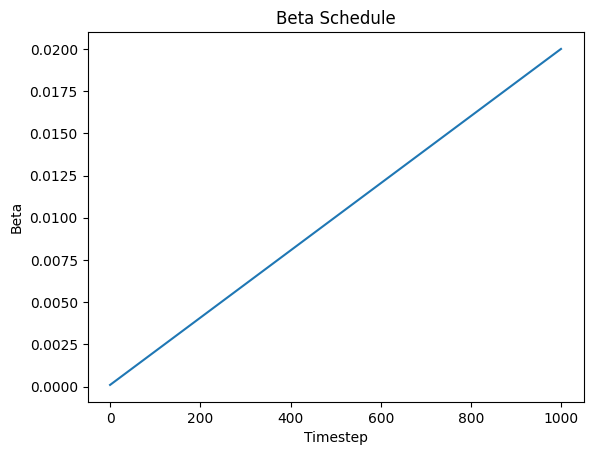

In [4]:
betas, alphas, alphas_bar = linear_beta_schedule(cfg.beta_0, cfg.beta_T, cfg.total_timesteps)
print("betas : ", betas.shape)
print("alphas : ", alphas.shape)

def write(text):
    with open(f'{cfg.output_dir}/logs.txt', 'a') as file:
        file.write(text)

from datetime import datetime
write(f"\n\nTraining start : {datetime.today().strftime('%Y-%m-%d %H:%M')}\n\n")

torch.cuda.empty_cache()

import matplotlib.pyplot as plt

plt.plot(betas.cpu())
plt.title("Beta Schedule")
plt.xlabel("Timestep")
plt.ylabel("Beta")
plt.show()

In [5]:
# from torchvision import datasets

# train_dataloader = torch.utils.data.DataLoader(
#     datasets.MNIST('./data/mnist', train=True, download=True,
#                   transform=transforms.Compose([
#                       transforms.Resize(32),
#                       transforms.ToTensor(),
#                       transforms.Lambda(lambda t: t.repeat(3, 1, 1)),  # [1,H,W] → [3,H,W]
#                       transforms.Lambda(lambda t: (t * 2) - 1)
#                   ])
#                  ),
#     batch_size=cfg.batch_size, shuffle=True
# )

# valid_dataloader = torch.utils.data.DataLoader(
#     datasets.MNIST('./data/mnist', train=False, download=True,
#                   transform=transforms.Compose([
#                       transforms.Resize(32),
#                       transforms.ToTensor(),
#                       transforms.Lambda(lambda t: t.repeat(3, 1, 1)),  # [1,H,W] → [3,H,W]
#                       transforms.Lambda(lambda t: (t * 2) - 1)
#                   ])
#                  ),
#     batch_size=cfg.batch_size, shuffle=False
# )

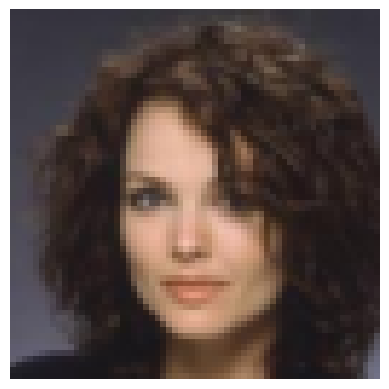

In [6]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F

# 예: image shape = (3, H, W), 값은 [0, 1]
def show_tensor_image(img_tensor):
    # tensor → numpy
    img = img_tensor.detach().cpu()
    if img.ndim == 4:  # 배치가 있을 경우 첫 번째 이미지만
        img = img[0]
    img = F.to_pil_image(img)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

show_tensor_image(next(iter(valid_dataloader))[0])

In [7]:
last_saved_epoch = 0
vae.eval()

def x_t_1_sample(x_t, timesteps, predicted_noise, z):
    moved_mean = torch.stack([x_t[idx] - (1-alphas[t])/(torch.sqrt(1-alphas_bar[t])) * predicted_noise[idx] for idx, t in enumerate(timesteps)])
    return torch.stack([1/torch.sqrt(alphas[t]) * moved_mean[idx] + torch.sqrt(betas[t]) * z[idx] for idx, t in enumerate(timesteps)])

def valid_step(epoch):
    model.eval()
    valid_loss = 0
    tqdm_bar = tqdm(total=len(valid_dataloader), desc="Diffusion validation")
    with torch.no_grad():
        for idx, data in enumerate(valid_dataloader):
            # data, labels = batch[0], batch[1]
            x_0 = data.to(device)
            with torch.no_grad():
                z_0 = vae.encode(x_0)
                z_0 = z_0['latent_dist'].sample() * cfg.latent_scale
            
            b, c, h, w = z_0.shape
            z_0 = z_0.permute(0, 2, 3, 1).reshape(b, h*w, c)
            
            timesteps = torch.randint(0, 1000, (b,))
            added_noise = torch.randn_like(z_0)
            
            z_t = x_t_sample(z_0, timesteps, added_noise, alphas_bar)
            z_t = z_t.to(device)
            timesteps = timesteps.to(device)
            added_noise = added_noise.to(device)
    
            predicted_noise = model(z_t, timesteps)
            
            loss = torch.nn.functional.mse_loss(added_noise, predicted_noise)
            
            valid_loss += loss.cpu().detach().item()
            tqdm_bar.update()

            # Inference Sampling for visual evaluation
            if idx==0:
                do_clip = partial(torch.clamp, min = -1., max = 1.)
                ddpm_timesteps = torch.linspace(999, 0, 1000).long().to(device)
                z_t = torch.randn_like(z_0).to(device) # start from z_T
                
                for i in range(len(ddpm_timesteps) - 1):
                    t = ddpm_timesteps[i]
                
                    t_batch = torch.full((b,), t.item(), dtype=torch.float32, device=device)
                    pred_noise = model(z_t, t_batch)
                
                    z = torch.randn_like(z_t)
                    z_t_1 = x_t_1_sample(z_t, t_batch.long(), pred_noise, z)
                    z_t = z_t_1.to(device)
                    # z_t = do_clip(z_t)
    
                z_t = rearrange(z_t, "b (x y) c -> b c x y", x=w, y=h)
                
                predicted_image = vae.decode(z_t / cfg.latent_scale)['sample']
                # -1 ~ 1로 나오니까
                # predicted_image = z_t
                trainer['valid_images'].append((predicted_image[:8].cpu().detach()/2+0.5).clamp(0, 1))
                del ddpm_timesteps
                del predicted_image
    
    del loss
    del predicted_noise
    del added_noise
    del timesteps
    del z_t
    torch.cuda.empty_cache()
    
    # per data loss
    val_loss = valid_loss/len(valid_dataloader)
    trainer['valid_losses'].append(val_loss)
    
    if val_loss <= min(trainer['valid_losses']):
        torch.save(model.state_dict(), f'{cfg.output_dir}/weights/model_{epoch}.pth')
    
    valid_text=f'Epoch {epoch} Validation loss - {val_loss}\n\n'
    write(valid_text)
    
    plt.plot(trainer['train_losses'])
    plt.savefig(f'{cfg.output_dir}/train_loss.png')
    plt.close()
    
    plt.plot(trainer['valid_losses'])
    plt.savefig(f'{cfg.output_dir}/valid_loss.png')
    plt.close()
    
    visualize(trainer['valid_images'][-1], epoch=epoch, save=True, output_dir=cfg.output_dir)

In [ ]:
import time

vae.eval()
last_saved_epoch = 0

sigma_min = 1e-5
# timestep은 0~1000이 아니라 0~1 사이 실수 값 : t = torch.rand((b, ), dtype=z_0.dtype, device=device)
# t = rearrange(t, "b -> b () ()")
# zt = (1 - (1 - sigma_min)*t) * z_T) + t * z_0
# target_flow = z_0 - (1 - sigma_min) * z_T

for epoch in range(cfg.epochs):
    model.train()
    epoch_loss = 0
    tqdm_bar = tqdm(total=len(train_dataloader), desc="Latent DiT DDPM Training")
    
    for idx, data in enumerate(train_dataloader):
        # data, labels = batch[0], batch[1]
        x_0 = data.to(device)

        # # 2) VAE encode
        with torch.no_grad():
            z_0 = vae.encode(x_0)
            z_0 = z_0['latent_dist'].sample() * cfg.latent_scale

        # Flatten latent
        b, c, h, w = z_0.shape
        z_0 = z_0.permute(0, 2, 3, 1).reshape(b, h*w, c)

        # 3) DDPM noising
        timesteps = torch.randint(0, 1000, (b,))
        added_noise = torch.randn_like(z_0)
        z_t = x_t_sample(z_0, timesteps, added_noise, alphas_bar)
        z_t = z_t.to(device)
        timesteps = timesteps.to(device)
        added_noise = added_noise.to(device)

        # 4) 모델 예측
        predicted_noise = model(z_t, timesteps)

        # Loss 계산
        loss = torch.nn.functional.mse_loss(added_noise, predicted_noise)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        tqdm_bar.update()
        epoch_loss += loss.cpu().detach().item()
        # print("loss - ", loss)

    if epoch<50:
        for param_group in optimizer.param_groups:
            param_group['lr'] *= 0.98

    trainer['train_losses'].append(epoch_loss/len(train_dataloader))
    train_text = f'Epoch {epoch} Train loss - {epoch_loss / len(train_dataloader)}\n'
    write(train_text)

    del loss, predicted_noise, added_noise, timesteps, z_t
    torch.cuda.empty_cache()

    valid_step(epoch)

Latent DiT DDPM Training:  24%|██▎       | 151/636 [01:45<05:32,  1.46it/s]

In [ ]:
last_saved_epoch = 0
vae.eval()

def valid_step(epoch):
    model.eval()
    valid_loss = 0
    tqdm_bar = tqdm(total=len(valid_dataloader), desc="Diffusion validation")
    with torch.no_grad():
        for idx, batch in enumerate(valid_dataloader):
            data, labels = batch[0], batch[1]
            z_0 = data.to(device)
            # with torch.no_grad():
            #     z_0 = vae.encode(x_0)
            #     z_0 = z_0['latent_dist'].sample() * cfg.latent_scale
            
            b, c, h, w = z_0.shape
            z_0 = z_0.permute(0, 2, 3, 1).reshape(b, h*w, c)
            
            timesteps = torch.randint(0, 1000, (b,))
            added_noise = torch.randn_like(z_0)
            
            z_t = x_t_sample(z_0, timesteps, added_noise, alphas_bar)
            z_t = z_t.to(device)
            timesteps = timesteps.to(device)
            added_noise = added_noise.to(device)
    
            predicted_noise = model(z_t, timesteps)
            
            loss = torch.nn.functional.mse_loss(added_noise, predicted_noise)
            
            valid_loss += loss.cpu().detach().item()
            tqdm_bar.update()

            # Inference Sampling for visual evaluation
            if idx==0:
                ddim_timesteps = torch.linspace(999, 0, 100).long().to(device)
                z_t = torch.randn_like(z_0).to(device) # start from z_T
                
                for i in range(len(ddim_timesteps) - 1):
                    t = ddim_timesteps[i]
                    t_next = ddim_timesteps[i+1]
                
                    t_batch = torch.full((b,), t.item(), dtype=torch.float32, device=device)
                    pred_noise = model(z_t, t_batch)
                
                    ab_t = alphas_bar[t].expand(b)
                    ab_t_next = alphas_bar[t_next].expand(b)
                    z_t = ddim_sample(z_t, t_batch, pred_noise, ab_t, ab_t_next).detach().to(torch.float32)
    
                z_t = rearrange(z_t, "b (x y) c -> b c x y", x=w, y=h)
                
                # predicted_image = vae.decode(z_t)
                predicted_image = z_t
                trainer['valid_images'].append(predicted_image[:8].cpu().detach()/2+0.5)
                # trainer['valid_images'].append(predicted_image['sample'][:8].cpu().detach()/2+0.5)
                del ddim_timesteps
                del predicted_image
    
    del loss
    del predicted_noise
    del added_noise
    del timesteps
    del z_t
    torch.cuda.empty_cache()
    
    # per data loss
    val_loss = valid_loss/len(valid_dataloader)
    
    trainer['valid_losses'].append(val_loss)
    
    if val_loss <= min(trainer['valid_losses']):
        torch.save(model.state_dict(), f'{cfg.output_dir}/weights/model_{epoch}.pth')
    
    valid_text=f'Epoch {epoch} Validation loss - {val_loss}\n\n'
    write(valid_text)
    
    plt.plot(trainer['train_losses'])
    plt.savefig(f'{cfg.output_dir}/train_loss.png')
    plt.close()
    
    plt.plot(trainer['valid_losses'])
    plt.savefig(f'{cfg.output_dir}/valid_loss.png')
    plt.close()
    
    visualize(trainer['valid_images'][-1], epoch=epoch, save=True, output_dir=cfg.output_dir)

In [ ]:
batch = next(iter(valid_dataloader))
data, labels = batch[0], batch[1]

x_0 = data.to(device)
with torch.no_grad():
    z_0 = vae.encode(x_0)
    z_0 = z_0['latent_dist'].sample() * cfg.latent_scale

b, c, h, w = z_0.shape
z_0 = z_0.permute(0, 2, 3, 1).reshape(b, h*w, c)
print("Z_0 : ", z_0.shape)

In [ ]:
ddim_timesteps = torch.linspace(999, 0, 100).long().to(device)
z_t = torch.randn_like(z_0).to(device) # start from z_T

In [ ]:
from tqdm import tqdm
from utils.sample import ddpm_sample

ddpm_timesteps = torch.linspace(999, 0, 1000).long().to(device)
z_t = torch.randn_like(z_0).to(device) # start from z_T

for i in tqdm(range(len(ddpm_timesteps) - 1)):
    t = ddpm_timesteps[i]
    t_next = ddpm_timesteps[i+1]

    t_batch = torch.full((b,), t.item(), dtype=torch.long, device=device)
    pred_noise = model(z_t, t_batch)

    z = torch.randn_like(z_t).to(device)
    z_t = ddpm_sample(z_t, t_batch, pred_noise, z, betas, alphas, alphas_bar).detach().to(torch.float32)
    z_t=z_t.clamp(-3., 3.)
    if i%50==0:
        print(z_t.max(), z_t.min(), " -- ", z_t.std())

In [ ]:
z_t.shape

In [ ]:
z_t = rearrange(z_t, "b (x y) c -> b c x y", x=4, y=4)
z_t.shape

In [ ]:
z_t.min()

In [ ]:
predicted_image = vae.decode(z_t/z_t.std())
# predicted_image = z_t
print(predicted_image['sample'].max())
print(predicted_image['sample'].min())

In [ ]:
z_0.std()

In [ ]:
print(z_t.mean())
print(z_t.std())

In [ ]:
show_tensor_image(predicted_image['sample'][:8].cpu().detach()/2 + 0.5)

In [ ]:
alphas_bar[0]

In [ ]:
import torch
import torch.nn as nn

conv = nn.Conv1d(4, 4, kernel_size=3, stride=1, padding=1)
a = torch.tensor((8, 4, 2)) # bs, n, d